In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
# link of the dataset
# https://huggingface.co/datasets/arbml/ashaar/tree/main/data
df = pd.read_parquet('../../datasets/ashaar_dataset/train-00000-of-00002.parquet')

In [4]:
# to remove rows with empty themes
dff = df[df["poem theme"].notna()]

# to remove rows with empty verses
dfff = dff[dff["poem verses"].notna()]

In [5]:
# the themes we will keep
list_of_requierd = ["قصيدة غزل","قصيدة هجاء","قصيدة مدح","قصيدة رثاء"]

In [6]:
# number of samples in each category
dfff["poem theme"].value_counts()

poem theme
قصيدة قصيره       25911
قصيدة عامه        20611
قصيدة مدح          5165
قصيدة رومنسيه      4074
قصيدة حزينه        2277
قصيدة عتاب         2032
قصيدة هجاء         1614
قصيدة غزل          1416
قصيدة دينية        1186
قصيدة رثاء          917
قصيدة شوق           901
قصيدة فراق          591
قصيدة ذم            420
قصيدة وطنيه         343
قصيدة الاناشيد       28
قصيدة سياسية         16
قصيدة المعلقات       10
قصيدة اعتذار          8
Name: count, dtype: int64

In [7]:
# to keep only bahers that have more than 900 samples
data = dfff
dfs = pd.DataFrame(data)
column_name = 'poem theme'
min_count = 900
counts = dfs[column_name].value_counts()
frequent_values = counts[counts > min_count].index
filtered_df = dfs[dfs[column_name].isin(frequent_values)]

In [8]:
# themes that has more than 900 samples
print(filtered_df["poem theme"].value_counts())

poem theme
قصيدة قصيره      25911
قصيدة عامه       20611
قصيدة مدح         5165
قصيدة رومنسيه     4074
قصيدة حزينه       2277
قصيدة عتاب        2032
قصيدة هجاء        1614
قصيدة غزل         1416
قصيدة دينية       1186
قصيدة رثاء         917
قصيدة شوق          901
Name: count, dtype: int64


In [9]:
# to keep only 900 samples from each category (to balance the dataset)
df_sampled = filtered_df.groupby('poem theme').head(900)

In [10]:
# to keep only four themes
dff_sampled = df_sampled[df_sampled["poem theme"].isin(list_of_requierd)]

In [11]:
# to remove tshkeel from verses
verses = []
for x in dff_sampled["poem verses"]:
    text = re.sub(r'[\u064B-\u065F]', '', str(' '.join(x.tolist())))
    verses.append(text)

In [12]:
# to convert verses to their vectory representation
vectorizer = TfidfVectorizer(ngram_range=(1,5),max_features=8000)
X = vectorizer.fit_transform(verses)  # Sparse, high-dimensional

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, dff_sampled["poem theme"], test_size=0.1, random_state=42)

In [14]:
clf = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', MultinomialNB()),
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', MaxAbsScaler()), ('clf', MultinomialNB())])

In [15]:
accuracy = clf.score(X_train, y_train)
print(f"Train Accuracy: {accuracy * 100:.2f}%")
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 92.19%
Test Accuracy: 50.28%


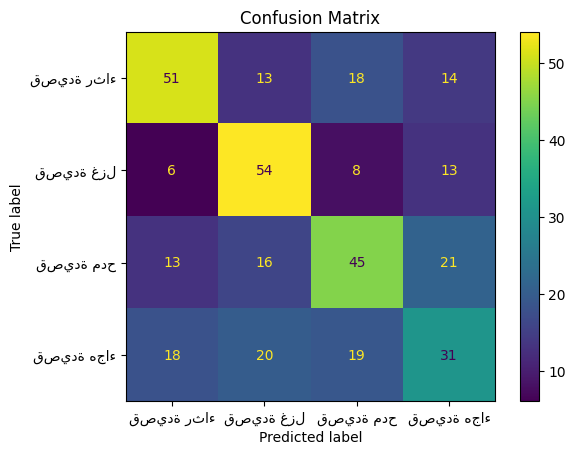

In [16]:
y_pred = clf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()

In [22]:
import joblib

# Save nb model
joblib.dump(clf, '../../models/poetry_classification_models/classify_by_theme/ashaar_dataset_theme_classification_naive_bayes_model.pkl')

['../../models/poetry_classification_models/classify_by_theme/ashaar_dataset_theme_classification_naive_bayes_model.pkl']